# 📊 Projeto Avaliativo - Módulo 1

### Aluno: Orlando Vieira de Castro Junior
### Turma: Visualização de Dados e Business Intelligence [T2]
---

### Análise Exploratória de Dados (EDA)

Objetivo deste projeto é realizar uma análise exploratória de dados (EDA) utilizando um conjunto de dados fornecido. A EDA é uma etapa crucial no processo de análise de dados, pois permite compreender melhor os dados, identificar padrões, detectar anomalias e gerar insights iniciais que podem orientar análises futuras.

**1. Importação de Bibliotecas**
   - Importar as bibliotecas necessárias para a análise de dados, como `pandas`, `numpy`, `matplotlib`, `duckdb` e `seaborn`.

In [45]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb as db
import seaborn as sns

**2. Importando os dados de funcionários por região e fazendo uma análise exploratória inicial para entender os dados.**

In [46]:
# Importar os dados de funcionários por região
funcionarios = pd.read_csv('/Users/Dell/Documents/GitHub/SCTEC_Modulo_I_Projeto_Final/dados/funcionarios_por_regiao.csv')

# Exibir informações básicas sobre o dataset
print(f"Dataset carregado: {funcionarios.shape[0]} linhas x {funcionarios.shape[1]} colunas")
print()
print("Colunas disponíveis:")
for i, col in enumerate(funcionarios.columns, 1):
    print(f"  {i:2}. {col}")

print()
print("=== Primeiras 10 linhas ===")
print(funcionarios.head(10).to_string())


Dataset carregado: 106 linhas x 13 colunas

Colunas disponíveis:
   1. EMPLOYEE_ID
   2. FIRST_NAME
   3. LAST_NAME
   4. SALARY
   5. DEPARTMENT_ID
   6. DEPARTMENT_NAME
   7. LOCATION_ID
   8. CITY
   9. STATE_PROVINCE
  10. COUNTRY_ID
  11. COUNTRY_NAME
  12. REGION_ID
  13. REGION_NAME

=== Primeiras 10 linhas ===
   EMPLOYEE_ID FIRST_NAME  LAST_NAME  SALARY  DEPARTMENT_ID DEPARTMENT_NAME  LOCATION_ID     CITY STATE_PROVINCE COUNTRY_ID              COUNTRY_NAME  REGION_ID REGION_NAME
0          201    Michael   Martinez   13000             20       Marketing         1800  Toronto        Ontario         CA                    Canada         20    Americas
1          202        Pat      Davis    6000             20       Marketing         1800  Toronto        Ontario         CA                    Canada         20    Americas
2          205    Shelley    Higgins   12008            110      Accounting         1700  Seattle     Washington         US  United States of America         20 

In [47]:
print("=== Estrutura da base ===")
funcionarios.info()

=== Estrutura da base ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   SALARY           106 non-null    int64 
 4   DEPARTMENT_ID    106 non-null    int64 
 5   DEPARTMENT_NAME  106 non-null    object
 6   LOCATION_ID      106 non-null    int64 
 7   CITY             106 non-null    object
 8   STATE_PROVINCE   105 non-null    object
 9   COUNTRY_ID       106 non-null    object
 10  COUNTRY_NAME     106 non-null    object
 11  REGION_ID        106 non-null    int64 
 12  REGION_NAME      106 non-null    object
dtypes: int64(5), object(8)
memory usage: 10.9+ KB


**Análise**

O dataset não possui valores nulos pois a consulta SQL utilizada para gerar o arquivo .CSV foi feita com a cláusula `WHERE` que filtrou apenas as regiões (`REGION_NAME`) que possuem valores válidos. Portanto, não há necessidade de tratar valores nulos neste caso.

In [48]:
# Exibindo as estatísticas dos campos numéricos
print("=== Estatísticas numéricas ===")
print(funcionarios.describe().round(2).to_string())

=== Estatísticas numéricas ===
       EMPLOYEE_ID    SALARY  DEPARTMENT_ID  LOCATION_ID  REGION_ID
count       106.00    106.00         106.00       106.00     106.00
mean        152.76   6456.75          63.21      1875.47      16.60
std          31.08   3927.80          20.91       460.40       4.76
min         100.00   2100.00          10.00      1400.00      10.00
25%         126.25   3100.00          50.00      1500.00      10.00
50%         152.50   6150.00          50.00      1700.00      20.00
75%         179.75   8950.00          80.00      2500.00      20.00
max         206.00  24000.00         110.00      2700.00      20.00


**Análise**

Das estatísticas descritivas acima, apenas a coluna `SALARY` apresenta valores numéricos, enquanto as demais colunas são códigos. A coluna `SALARY` possui uma média de 6.456,75, uma mediana (2º quartil) de 6.150,00, um valor mínimo de 2.100,00 e um valor máximo de 24.000,00. 

**3. Importando os dados de salários por departamento e cargo e realizando uma análise exploratória inicial para entender os dados.**

In [49]:
# Importar os dados de salários por departamento e cargo 
salarios = pd.read_csv('/Users/Dell/Documents/GitHub/SCTEC_Modulo_I_Projeto_Final/dados/salarios_por_depto_cargo.csv')

# Exibir informações básicas sobre o dataset
print(f"Dataset carregado: {salarios.shape[0]} linhas x {salarios.shape[1]} colunas")
print()
print("Colunas disponíveis:")
for i, col in enumerate(salarios.columns, 1):
    print(f"  {i:2}. {col}")

print()
print("=== Primeiras 10 linhas ===")
print(salarios.head(10).to_string())

Dataset carregado: 106 linhas x 11 colunas

Colunas disponíveis:
   1. EMPLOYEE_ID
   2. FIRST_NAME
   3. LAST_NAME
   4. HIRE_DATE
   5. DEPARTMENT_ID
   6. DEPARTMENT_NAME
   7. JOB_ID
   8. JOB_TITLE
   9. SALARY
  10. MIN_SALARY
  11. MAX_SALARY

=== Primeiras 10 linhas ===
   EMPLOYEE_ID   FIRST_NAME LAST_NAME             HIRE_DATE  DEPARTMENT_ID DEPARTMENT_NAME      JOB_ID                      JOB_TITLE  SALARY  MIN_SALARY  MAX_SALARY
0          205      Shelley   Higgins  2012-06-07T00:00:00Z            110      Accounting      AC_MGR             Accounting Manager   12008        8200       16000
1          206      William     Gietz  2012-06-07T00:00:00Z            110      Accounting  AC_ACCOUNT              Public Accountant    8300        4200        9000
2          200     Jennifer    Whalen  2013-09-17T00:00:00Z             10  Administration     AD_ASST       Administration Assistant    4400        3000        6000
3          102          Lex    Garcia  2011-01-13T00:00:0

In [50]:
print("=== Estrutura da base ===")
salarios.info()

=== Estrutura da base ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   HIRE_DATE        106 non-null    object
 4   DEPARTMENT_ID    106 non-null    int64 
 5   DEPARTMENT_NAME  106 non-null    object
 6   JOB_ID           106 non-null    object
 7   JOB_TITLE        106 non-null    object
 8   SALARY           106 non-null    int64 
 9   MIN_SALARY       106 non-null    int64 
 10  MAX_SALARY       106 non-null    int64 
dtypes: int64(5), object(6)
memory usage: 9.2+ KB


**Análise**

O dataset não possui valores nulos pois a consulta SQL utilizada para gerar o arquivo .CSV foi feita com a cláusula `WHERE` que filtrou apenas os departamentos (`DEPARTMENT_ID`) que possuem valores válidos. Portanto, não há necessidade de tratar valores nulos neste caso.

In [51]:
# Exibindo as estatísticas dos campos numéricos
print("=== Estatísticas numéricas ===")
print(salarios.describe().round(2).to_string())

=== Estatísticas numéricas ===
       EMPLOYEE_ID  DEPARTMENT_ID    SALARY  MIN_SALARY  MAX_SALARY
count       106.00         106.00    106.00      106.00      106.00
mean        152.76          63.21   6456.75     4701.32     9708.79
std          31.08          20.91   3927.80     3037.95     5756.75
min         100.00          10.00   2100.00     2008.00     5000.00
25%         126.25          50.00   3100.00     2500.00     5500.00
50%         152.50          50.00   6150.00     4100.00     9000.00
75%         179.75          80.00   8950.00     6000.00    12008.00
max         206.00         110.00  24000.00    20080.00    40000.00


**Análises**

As estatísticas numéricas da coluna `SALARY` mostram uma média de 6.456,75, uma mediana de 6.150,00, um valor mínimo de 2.100,00 e um valor máximo de 24.000,00. 

Os dados indicam ainda que a faixa salarial para os cargos da empresa é ampla e varia de 2.008,00 (menor valor de `MIN_SALARY`) a 40.000,00 (maior valor de `MAX_SALARY`). 
As colunas `EMPLOYEE_ID` e `DEPARTMENT_ID` são códigos que representam os funcionários e os departamentos, respectivamente.

**3.1. Criação do banco de dados no duckdb.**

In [52]:
banco_dados = db.connect()
banco_dados.register('funcionarios', funcionarios) # registra a tabela funcionarios no banco de dados
banco_dados.register('salarios', salarios) # registra a tabela salarios no banco de dados


**4. Análises estatísticas e visualizações gráficas para explorar os dados de salários por departamento e cargo.**
    
* Nesta etapa, serão realizadas análises estatísticas e visualizações gráficas para explorar os dados de salários por departamento e cargo. As análises incluirão a distribuição dos salários, a média salarial por departamento e cargo, e a identificação de possíveis outliers.

**4.1. Distribuição dos salários por departamento**

 DEPARTMENT_NAME  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIOS
           Sales                  34        304500.0         8955.88
        Shipping                  45        156400.0         3475.56
       Executive                   3         58000.0        19333.33
         Finance                   6         51608.0         8601.33
              IT                   5         28800.0         5760.00
      Purchasing                   6         24900.0         4150.00
      Accounting                   2         20308.0        10154.00
       Marketing                   2         19000.0         9500.00
Public Relations                   1         10000.0        10000.00
 Human Resources                   1          6500.0         6500.00
  Administration                   1          4400.0         4400.00


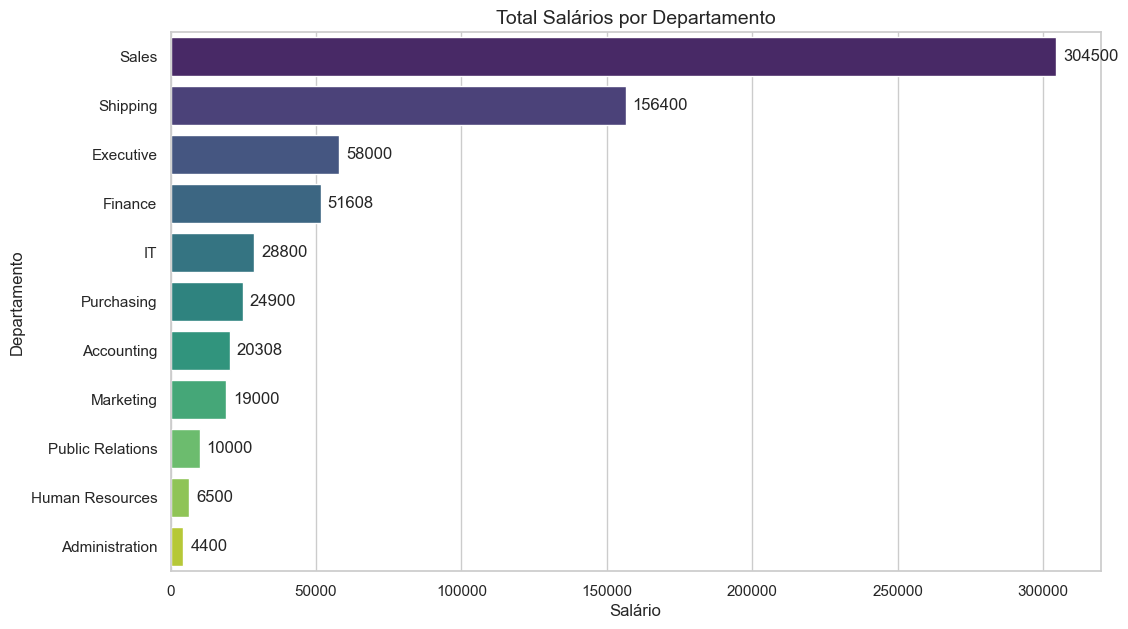

In [53]:
# Consulta SQL para calcular a total salarios por DEPARTAMENTO
total_salarios_departamento = """
SELECT 
    DEPARTMENT_NAME,
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIOS,
FROM SALARIOS
GROUP BY DEPARTMENT_NAME
ORDER BY TOTAL_SALARIOS DESC;
"""

# Executa a consulta e exibe o resultado
resultado_departamentos = banco_dados.execute(total_salarios_departamento).df()
print(resultado_departamentos.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado_departamentos,
    x='TOTAL_SALARIOS',
    y='DEPARTMENT_NAME',
    hue='DEPARTMENT_NAME',
    palette='viridis',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Total Salários por Departamento", fontsize=14)
plt.xlabel("Salário", fontsize=12)
plt.ylabel("Departamento", fontsize=12)

plt.show()

**Análises**

Os departamentos de Vendas (Sales) e Expedição (shipping) são responsáveis pelos maiores valores de salários pagos, com totais de 304.500,00 e 156.400,00, respectivamente. Trata-se de departamentos que possuem um grande número de funcionários, o que contribui para o alto valor total de salários pagos.

Por outro lado, os departamentos de Recursos Humanos (Human Resources) e Administração (Administration) apresentam os menores valores de salários pagos, com um total de 6.500,00 e 4.400,00, respectivamente e apena um funcionário em cada departamento. Isso indica que esses departamentos possuem um número reduzido de funcionários, o que resulta em um valor total de salários pagos menor.

**4.2. Distribuição dos salários por cargo**

                      JOB_TITLE  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIOS
           Sales Representative                  29        243500.0         8396.55
                 Shipping Clerk                  20         64300.0         3215.00
                  Sales Manager                   5         61000.0        12200.00
                    Stock Clerk                  20         55700.0         2785.00
                     Accountant                   5         39600.0         7920.00
                  Stock Manager                   5         36400.0         7280.00
  Administration Vice President                   2         34000.0        17000.00
                     Programmer                   5         28800.0         5760.00
                      President                   1         24000.0        24000.00
               Purchasing Clerk                   5         13900.0         2780.00
              Marketing Manager                   1         13000.0        1

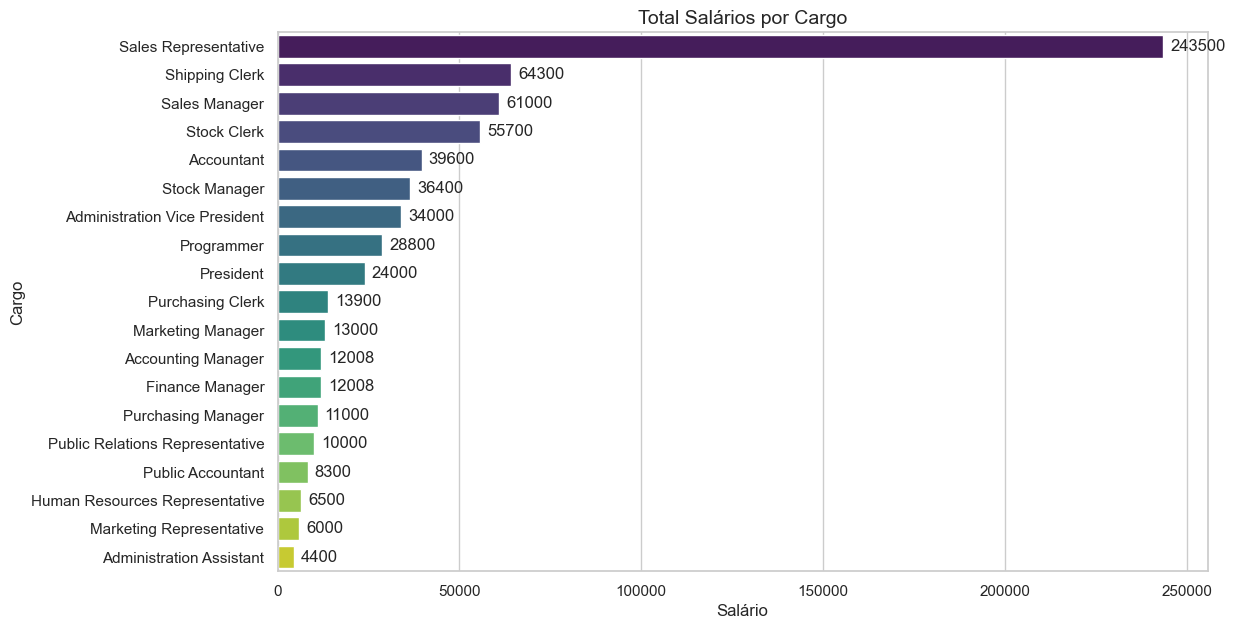

In [54]:
# Consulta SQL para calcular a total salarios por CARGO
total_salarios_cargo = """
SELECT 
    JOB_TITLE, 
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIOS
FROM SALARIOS
GROUP BY JOB_TITLE
ORDER BY TOTAL_SALARIOS DESC;
"""

# Executa a consulta e exibe o resultado
resultado_cargos = banco_dados.execute(total_salarios_cargo).df()
print(resultado_cargos.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado_cargos,
    x='TOTAL_SALARIOS',
    y='JOB_TITLE',
    hue='JOB_TITLE',
    palette='viridis',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Total Salários por Cargo", fontsize=14)
plt.xlabel("Salário", fontsize=12)
plt.ylabel("Cargo", fontsize=12)

plt.show()

**Análises**

Da mesma forma que no gráfico anterior, os cargos de Sales Representative e Shipping Clerk são responsáveis pelo maior valor de salários pagos, com um total de 243.500,00 e 64.300,00, respectivamente. Trata-se de cargos que possuem um grande número de funcionários, o que contribui para o alto valor total de salários pagos.

**4.3. Histograma da distribuição dos salários**

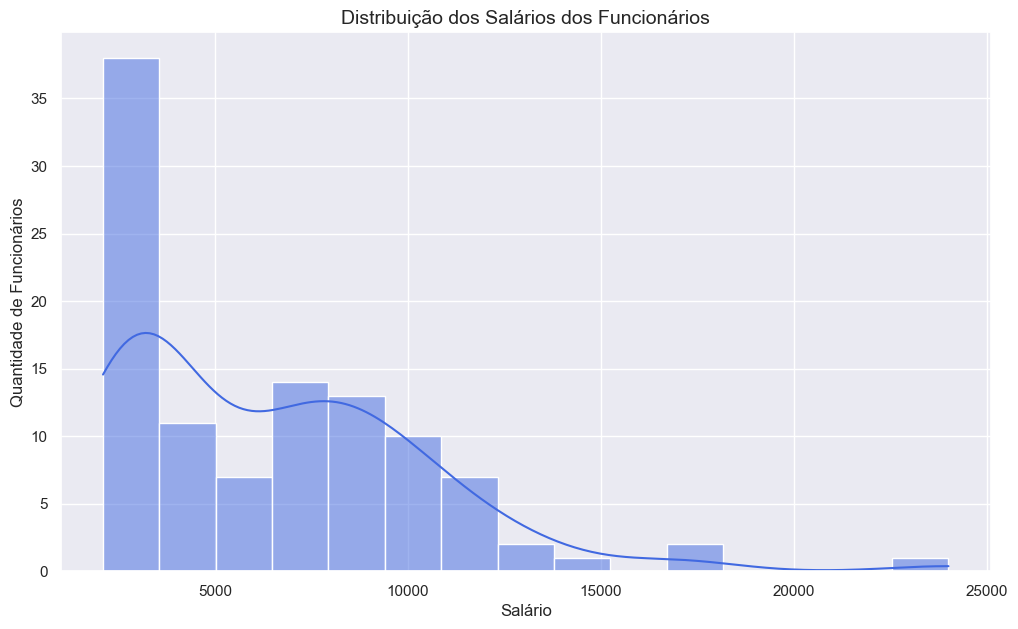

In [69]:
# Distribuição dos Salários do Funcionários

# 1. Configurar o estilo visual (opcional)
plt.figure(figsize=(12, 7))
sns.set_theme(style="darkgrid")

# 2. Criar o histograma (substitua 'idade' pelo nome da sua coluna)
sns.histplot(data=funcionarios, x="SALARY", kde=True, color="royalblue", bins=15)

# 3. Customizar os títulos
plt.title("Distribuição dos Salários dos Funcionários", fontsize=14)
plt.xlabel("Salário", fontsize=12)
plt.ylabel("Quantidade de Funcionários", fontsize=12)

# Salvando o gráfico 
plt.savefig('imagens/histograma_salarios.png', dpi=300, bbox_inches='tight')

# 4. Exibir o gráfico
plt.show()

**4.4. Média salarial por departamento**

 DEPARTMENT_NAME  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIAL
       Executive                   3         58000.0        19333.33
      Accounting                   2         20308.0        10154.00
Public Relations                   1         10000.0        10000.00
       Marketing                   2         19000.0         9500.00
           Sales                  34        304500.0         8955.88
         Finance                   6         51608.0         8601.33
 Human Resources                   1          6500.0         6500.00
              IT                   5         28800.0         5760.00
  Administration                   1          4400.0         4400.00
      Purchasing                   6         24900.0         4150.00
        Shipping                  45        156400.0         3475.56


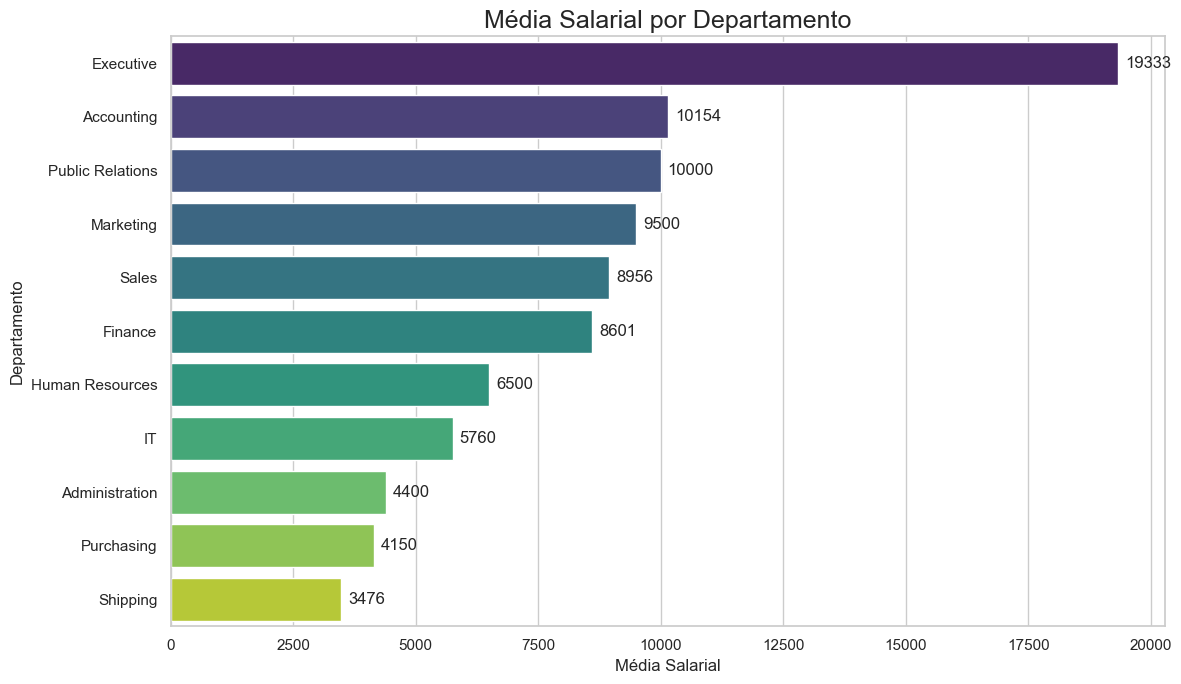

In [ ]:
# Média salarial por departamento

# Consulta SQL para calcular a média salarial por departamento
query = """
SELECT 
    DEPARTMENT_NAME, 
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIAL
    
FROM SALARIOS
GROUP BY DEPARTMENT_NAME
ORDER BY MEDIA_SALARIAL DESC;
"""

# Executa a consulta e exibe o resultado
resultado = banco_dados.execute(query).df()
print(resultado.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado,
    x='MEDIA_SALARIAL',
    y='DEPARTMENT_NAME',
    hue='DEPARTMENT_NAME',
    palette='viridis',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

# Customizando o gráfico
plt.xlabel('Média Salarial')
plt.ylabel('Departamento')
plt.title('Média Salarial por Departamento', fontsize=18)
plt.tight_layout()

# Salvando o gráfico 
plt.savefig('imagens/media_salarial_depto.png', dpi=300, bbox_inches='tight')

plt.show()

4.5. **Boxplot da distribuição dos salários por departamento**

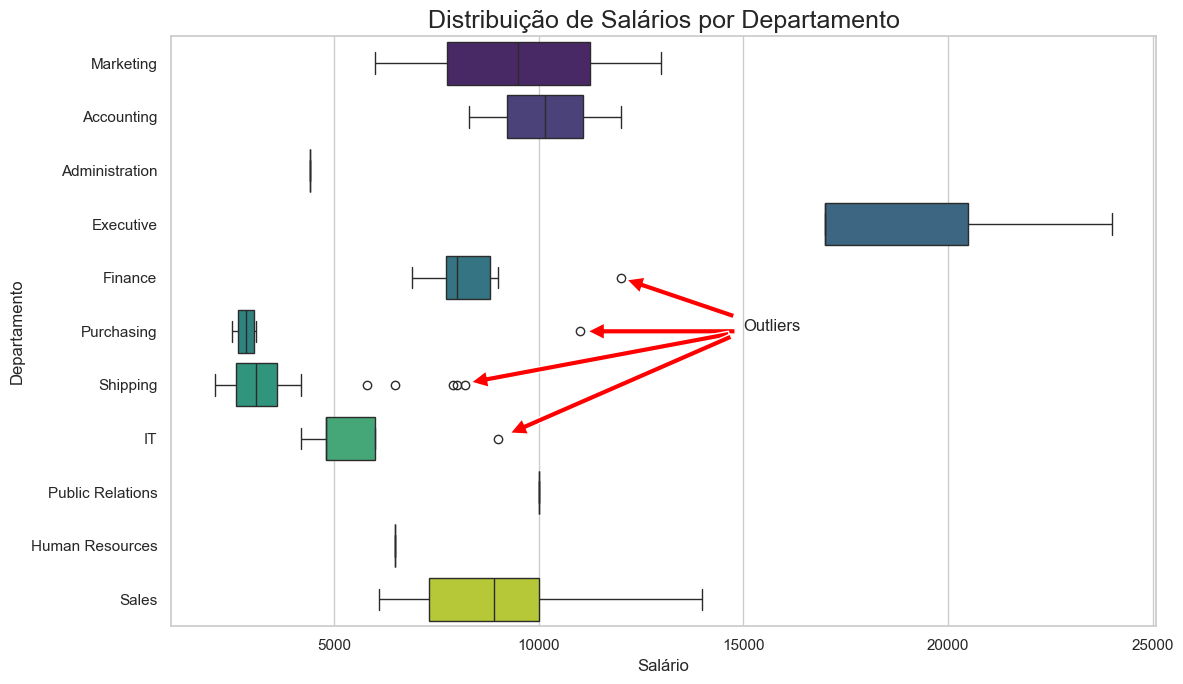

In [70]:
# Configuração de estilo
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Criação do Boxplot
sns.boxplot(
    data=funcionarios,
    x='SALARY',
    y='DEPARTMENT_NAME',
    hue='DEPARTMENT_NAME',
    palette='viridis',
    legend=False
)

plt.xlabel('Salário')
plt.ylabel('Departamento')
plt.title('Distribuição de Salários por Departamento', fontsize=18)
plt.tight_layout()
plt.annotate('Outliers', xy=(12000, 4), xytext=(15000, 5),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('', xy=(11000, 5), xytext=(15000, 5),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('', xy=(8000, 6), xytext=(15000, 5),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('', xy=(9000, 7), xytext=(15000, 5),
             arrowprops=dict(facecolor='red', shrink=0.05))

# Salvando o gráfico 
plt.savefig('imagens/boxplot_depto.png', dpi=300, bbox_inches='tight')

plt.show()

**Análises**

Verificou-se a existência de outliers nos departamentos de Finanças (Finance), Compras (Purchasing), Expedição (Shipping) e TI, com valores de salários significativamente mais altos do que a média dos demais funcionários desses departamentos. 

**4.6. Média salarial por cargo**

                      JOB_TITLE  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIAL
                      President                   1         24000.0        24000.00
  Administration Vice President                   2         34000.0        17000.00
              Marketing Manager                   1         13000.0        13000.00
                  Sales Manager                   5         61000.0        12200.00
             Accounting Manager                   1         12008.0        12008.00
                Finance Manager                   1         12008.0        12008.00
             Purchasing Manager                   1         11000.0        11000.00
Public Relations Representative                   1         10000.0        10000.00
           Sales Representative                  29        243500.0         8396.55
              Public Accountant                   1          8300.0         8300.00
                     Accountant                   5         39600.0         

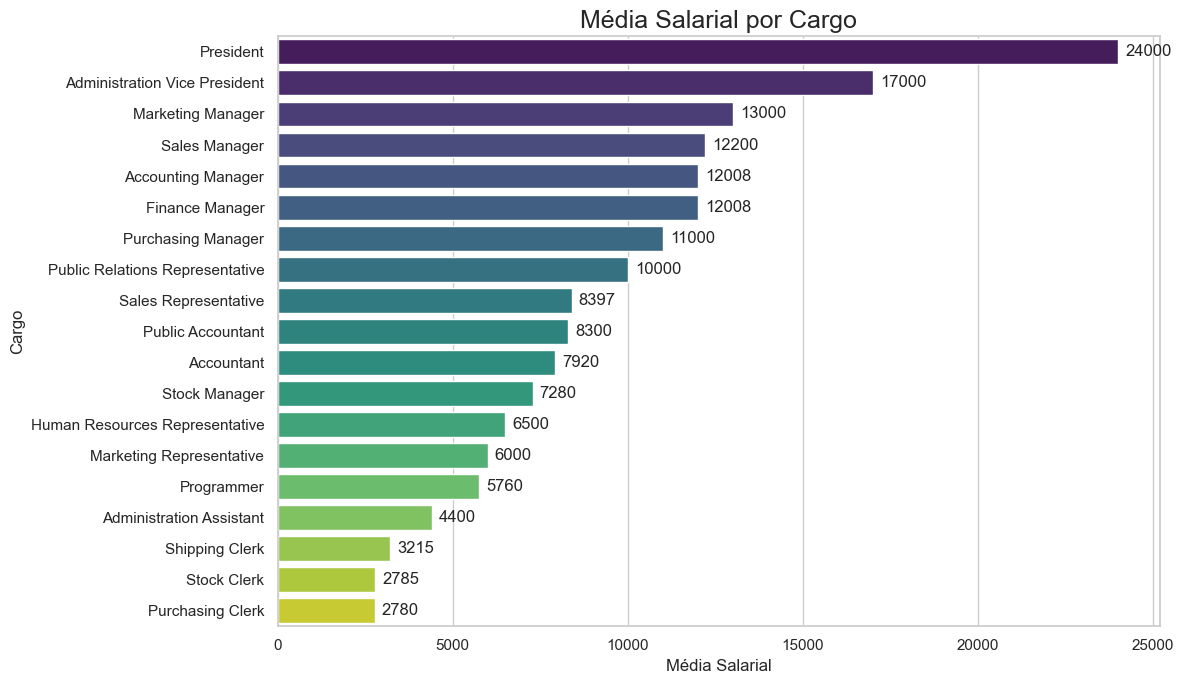

In [68]:
# Média salarial por Cargo

# Consulta SQL para calcular a média salarial por cargo
query = """
SELECT 
    JOB_TITLE, 
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIAL
FROM SALARIOS
GROUP BY JOB_TITLE
ORDER BY MEDIA_SALARIAL DESC;
"""

# Executa a consulta e exibe o resultado
resultado = banco_dados.execute(query).df()
print(resultado.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado,
    x='MEDIA_SALARIAL',
    y='JOB_TITLE',
    hue='JOB_TITLE',
    palette='viridis',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

# Customizando o gráfico
plt.xlabel('Média Salarial')
plt.ylabel('Cargo')
plt.title('Média Salarial por Cargo', fontsize=18)
plt.tight_layout()

# Salvando o gráfico em alta resolução
plt.savefig('imagens/media_salarial_cargo.png', dpi=300, bbox_inches='tight')

plt.show()

**Analises**

Os cargos da alta gestão da empresa (President, Administration Vice President, Marketing, Sales, Finance e Accounting Managers) apresentam os maiores valores de média salarial, com 24.000,00, 17.000,00, 13.000,00, 12.200,00, 12.008,00 e 12.008,00, respectivamente. Isso indica que esses cargos são altamente valorizados na empresa e possuem uma remuneração significativamente maior em comparação com outros cargos.

**4.7. Boxplot da distribuição dos salários por cargo**

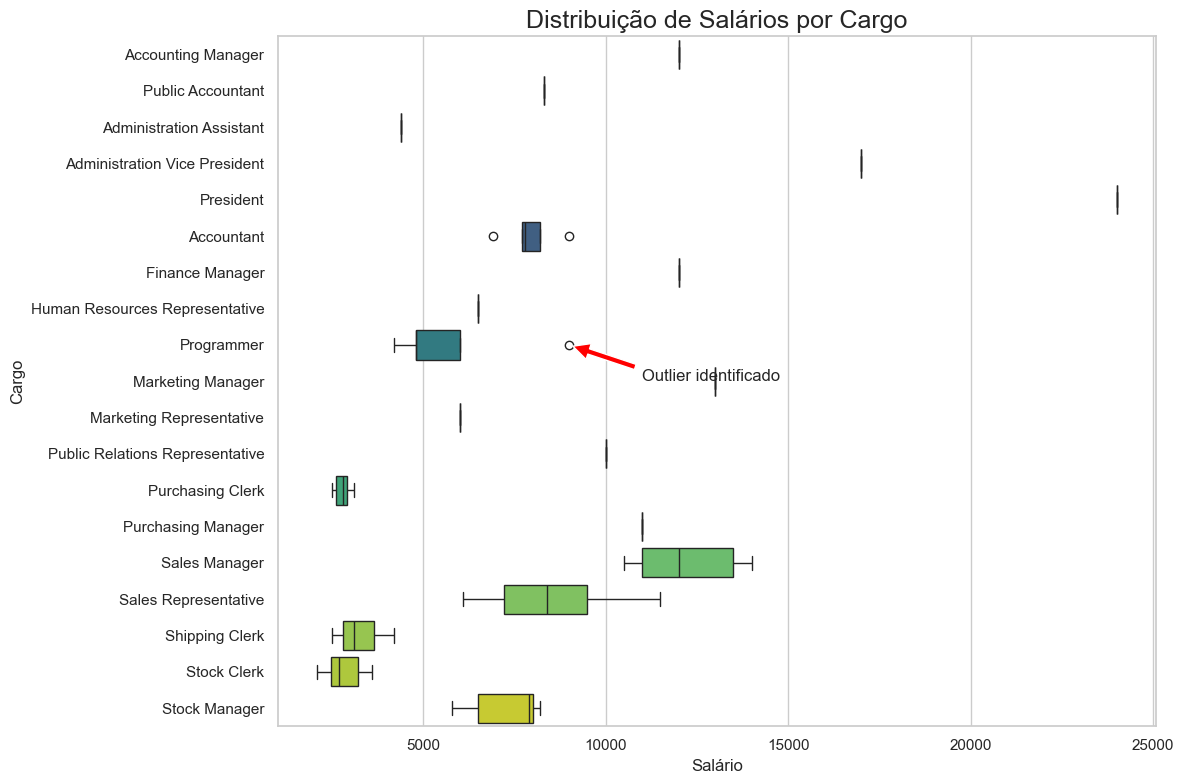

In [59]:
# Configuração de estilo
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Criação do Boxplot
sns.boxplot(
    data=salarios,
    x='SALARY',
    y='JOB_TITLE',
    hue='JOB_TITLE',
    palette='viridis',
    legend=False
)

plt.xlabel('Salário')
plt.ylabel('Cargo')
plt.title('Distribuição de Salários por Cargo', fontsize=18)
plt.tight_layout()
plt.annotate('Outlier identificado', xy=(9000, 8), xytext=(11000, 9),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

**Análises**

Verificou-se a existência de um outlier no cargo de Programador, com um valor de salário significativamente mais alto do que a média dos demais funcionários desse cargo.

**5. Análises estatísticas e visualizações gráficas para explorar os dados de funcionários e salários por país.** 
- Nesta etapa, serão realizadas análises estatísticas e visualizações gráficas para explorar os dados de funcionários por região e cargo. As análises incluirão a distribuição dos funcionários por região, analisando salários e distribuição geográfica (Cidade, Estado ou País), bem como a identificação de possíveis outliers.

**5.1 Ditribuição de funcionários por país**.

                                        COUNTRY_NAME  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIOS
                            United States of America                  68        344416.0         5064.94
United Kingdom of Great Britain and Northern Ireland                  35        311000.0         8885.71
                                              Canada                   2         19000.0         9500.00
                                             Germany                   1         10000.0        10000.00


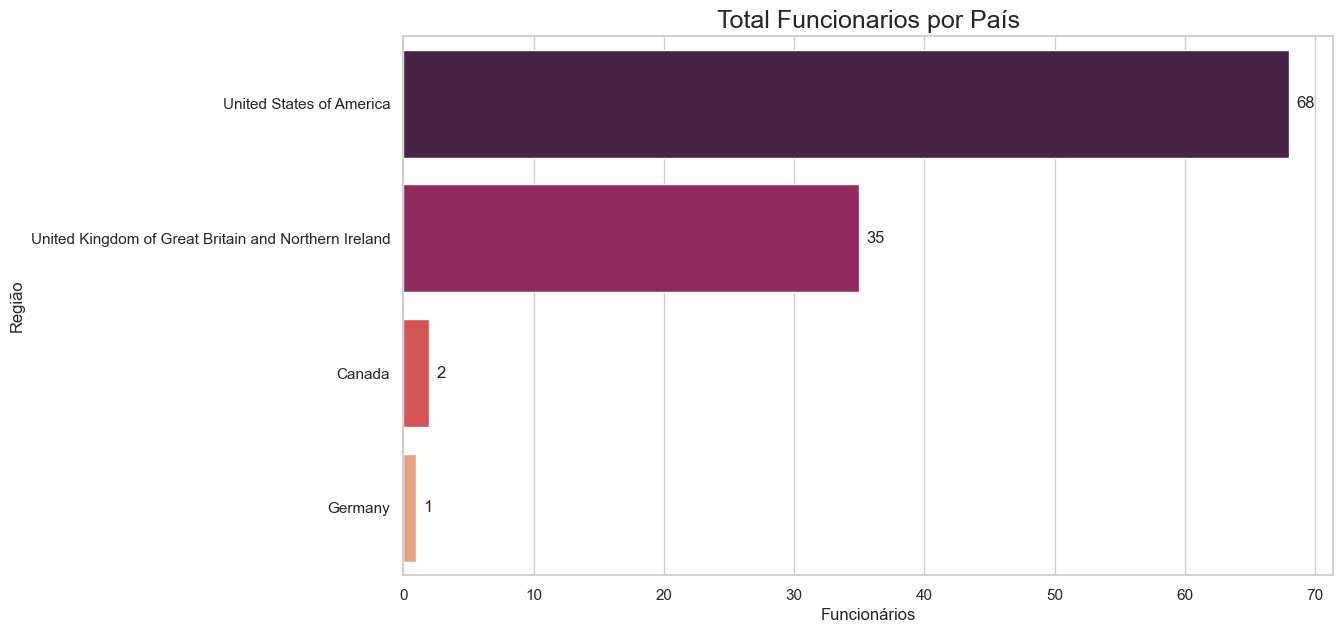

In [60]:
# Consulta SQL para calcular a total salarios por PAÍS
total_funcionarios_pais = """
SELECT 
    COUNTRY_NAME,
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIOS,
FROM FUNCIONARIOS
GROUP BY COUNTRY_NAME
ORDER BY TOTAL_FUNCIONARIOS DESC;
"""

# Executa a consulta e exibe o resultado
resultado_paises = banco_dados.execute(total_funcionarios_pais).df()
print(resultado_paises.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado_paises,
    x='TOTAL_FUNCIONARIOS',
    y='COUNTRY_NAME',
    hue='COUNTRY_NAME',
    palette='rocket',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Total Funcionarios por País", fontsize=18)
plt.xlabel("Funcionários", fontsize=12)
plt.ylabel("Região", fontsize=12)

plt.show()

**Análises**

A maioria dos funcionários da empresa está localizada nos Estados Unidos, com um total de 68 funcionários, seguido pelo Reino Unido, com 35 funcionários, pelo Canadá, com 19 funcionários. A Alemanha possui apenas um funcionário contratado como representante de relações públicas.

**5.2. Distribuição dos cargos por país**

                      JOB_TITLE                                         COUNTRY_NAME  NUM_FUNCIONARIOS
 Human Resources Representative United Kingdom of Great Britain and Northern Ireland                 1
       Administration Assistant                             United States of America                 1
                     Accountant                             United States of America                 5
                     Programmer                             United States of America                 5
             Purchasing Manager                             United States of America                 1
                 Shipping Clerk                             United States of America                20
                    Stock Clerk                             United States of America                20
             Accounting Manager                             United States of America                 1
       Marketing Representative                                          

<Figure size 1200x800 with 0 Axes>

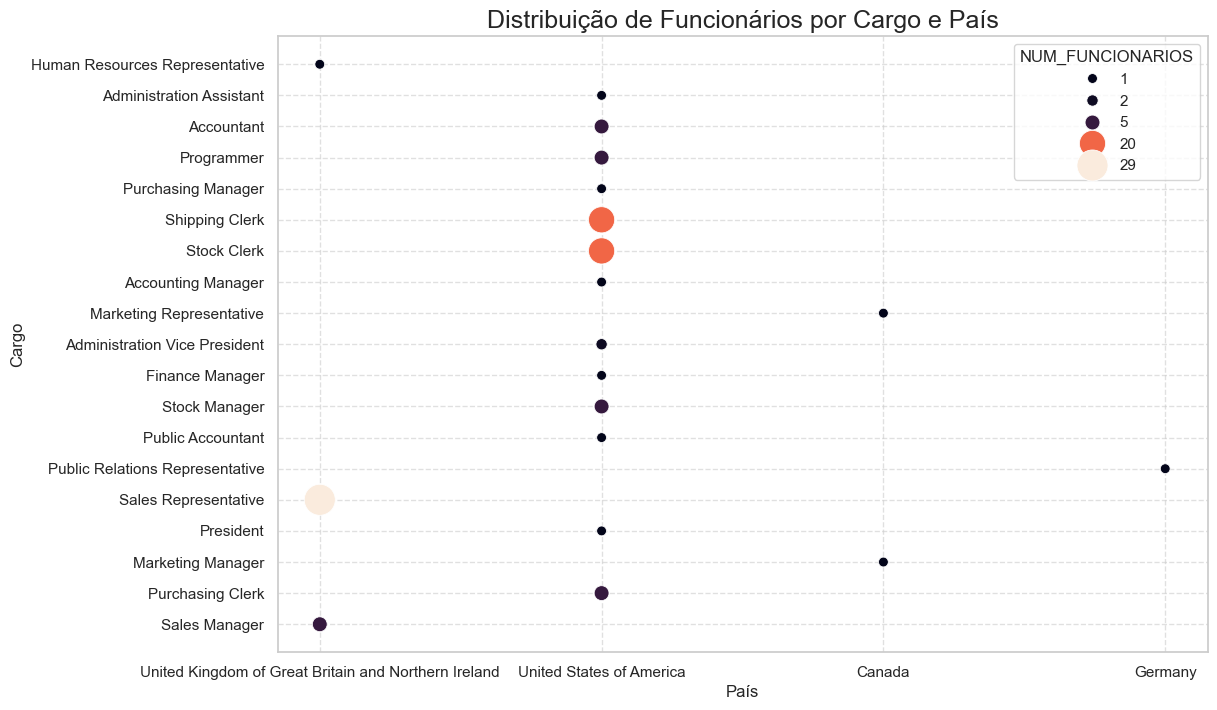

In [61]:
funcionarios_cargo_pais = """
SELECT 
    JOB_TITLE, 
    COUNTRY_NAME, 
    COUNT(f.EMPLOYEE_ID) AS NUM_FUNCIONARIOS
FROM SALARIOS s
LEFT JOIN FUNCIONARIOS f 
    ON s.EMPLOYEE_ID = f.EMPLOYEE_ID
GROUP BY s.JOB_TITLE, f.COUNTRY_NAME;
"""

# Executa a consulta e exibe o resultado
resultado_cargos_pais = banco_dados.execute(funcionarios_cargo_pais).df()
print(resultado_cargos_pais.to_string(index=False))

# Configuração de estilo
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Gráfico de dispersão (scatter plot) para visualizar a distribuição de funcionários por cargo e país
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=resultado_cargos_pais, 
    x='COUNTRY_NAME', 
    y='JOB_TITLE', 
    size='NUM_FUNCIONARIOS', 
    sizes=(50, 500), 
    hue='NUM_FUNCIONARIOS',
    palette='rocket',
)

plt.title('Distribuição de Funcionários por Cargo e País', fontsize=18)
plt.xlabel('País')
plt.ylabel('Cargo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Análises**

A maioria dos funcionários da empresa está localizada nos Estados Unidos. As posições na Alemanha, Canadá e Reino Unido são ocupadas por representantes de vendas, gerentes de marketing e representantes de relações públicas. Isso pode indicar que a empresa possui uma presença global e está expandindo suas operações em diferentes países.

**5.3. Distribuição de salários por País**

                                        COUNTRY_NAME  TOTAL_FUNCIONARIOS  TOTAL_SALARIOS  MEDIA_SALARIOS
                            United States of America                  68        344416.0         5064.94
United Kingdom of Great Britain and Northern Ireland                  35        311000.0         8885.71
                                              Canada                   2         19000.0         9500.00
                                             Germany                   1         10000.0        10000.00


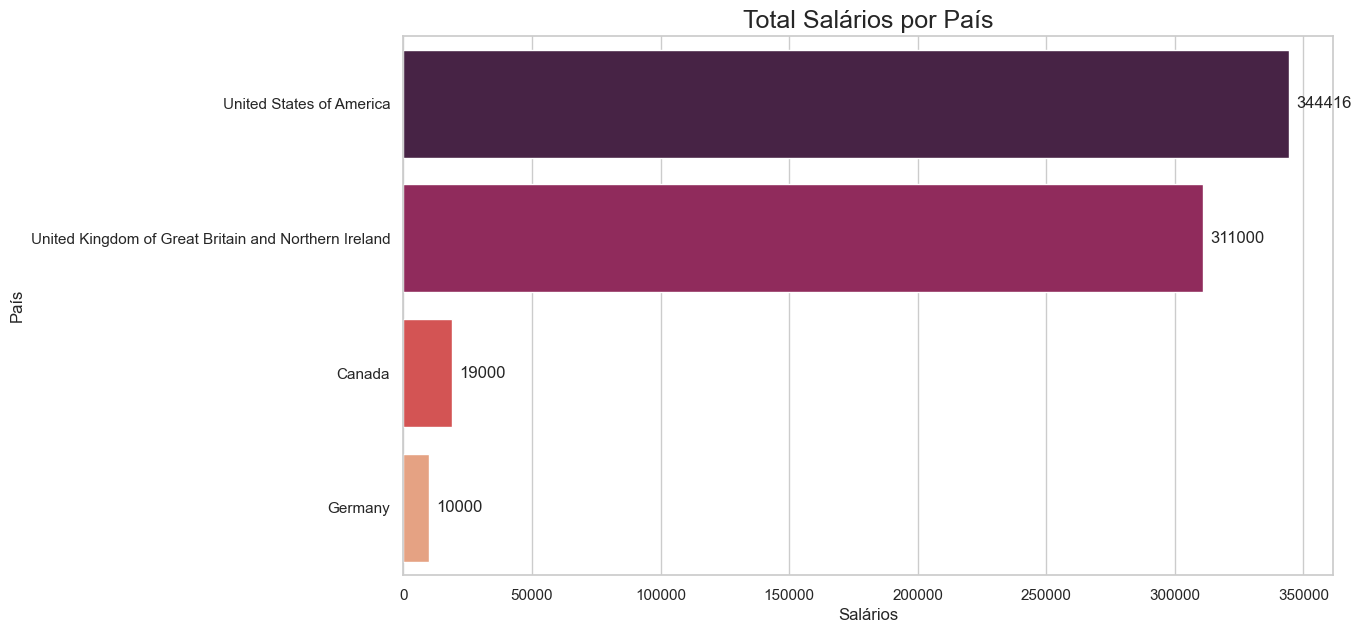

In [71]:
# Consulta SQL para calcular a total salarios por PAÍS
total_funcionarios_pais = """
SELECT 
    COUNTRY_NAME,
    COUNT(EMPLOYEE_ID) AS TOTAL_FUNCIONARIOS,
    ROUND((SUM(SALARY)),2) AS TOTAL_SALARIOS,
    ROUND((AVG(SALARY)),2) AS MEDIA_SALARIOS,
FROM FUNCIONARIOS
GROUP BY COUNTRY_NAME
ORDER BY TOTAL_SALARIOS DESC;
"""

# Executa a consulta e exibe o resultado
resultado_paises = banco_dados.execute(total_funcionarios_pais).df()
print(resultado_paises.to_string(index=False))

# Configuração do estilo Seaborn
sns.set_theme(style="whitegrid")

# Configuração do gráfico
plt.figure(figsize=(12, 7))

# Criando o gráfico
ax = sns.barplot(
    data=resultado_paises,
    x='TOTAL_SALARIOS',
    y='COUNTRY_NAME',
    hue='COUNTRY_NAME',
    palette='rocket',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Total Salários por País", fontsize=18)
plt.xlabel("Salários", fontsize=12)
plt.ylabel("País", fontsize=12)

# Salvando o gráfico 
plt.savefig('imagens/salario_total_pais.png', dpi=300, bbox_inches='tight')

plt.show()

**Análises**

Como a maioria dos funcionários da empresa está localizada nos Estados Unidos, é natural que o país apresente o maior valor de salários pagos, com um total de 344.416,00.

**5.4. Salário médio por País**

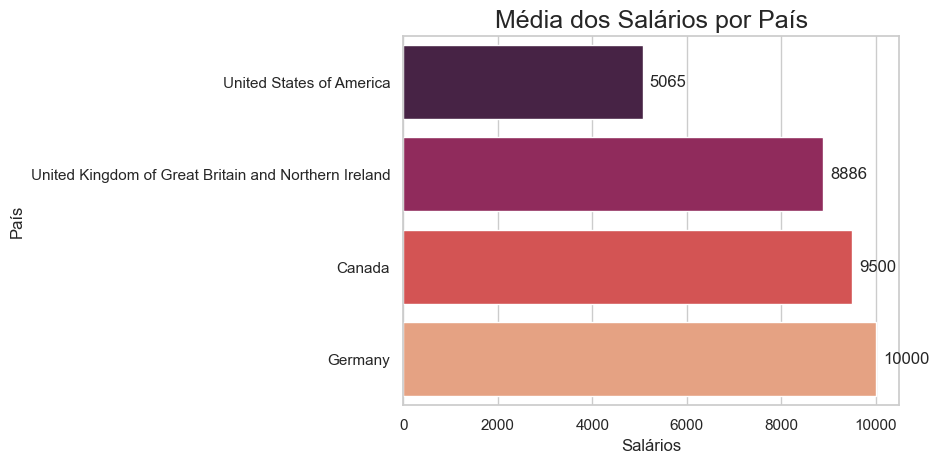

In [73]:
# Criando o gráfico
ax = sns.barplot(
    data=resultado_paises,
    x='MEDIA_SALARIOS',
    y='COUNTRY_NAME',
    hue='COUNTRY_NAME',
    palette='rocket',
    legend=False
)

# Adicionando os valores das médias salariais nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Média dos Salários por País", fontsize=18)
plt.xlabel("Salários", fontsize=12)
plt.ylabel("País", fontsize=12)

# Salvando o gráfico 
plt.savefig('imagens/salario_medio_pais.png', dpi=300, bbox_inches='tight')

plt.show()

**Análises**

Apesar de existirem poucos funcionários em alguns países, como Alemanha e Canadá, o salário médio nesses países é relativamente alto, com 9.500,00 e 10.000,00, respectivamente. Isso pode indicar que a empresa valoriza e remunera bem os funcionários em cargos estratégicos ou especializados nesses países.

**5.5. Boxplot da distribuição dos salários por País**

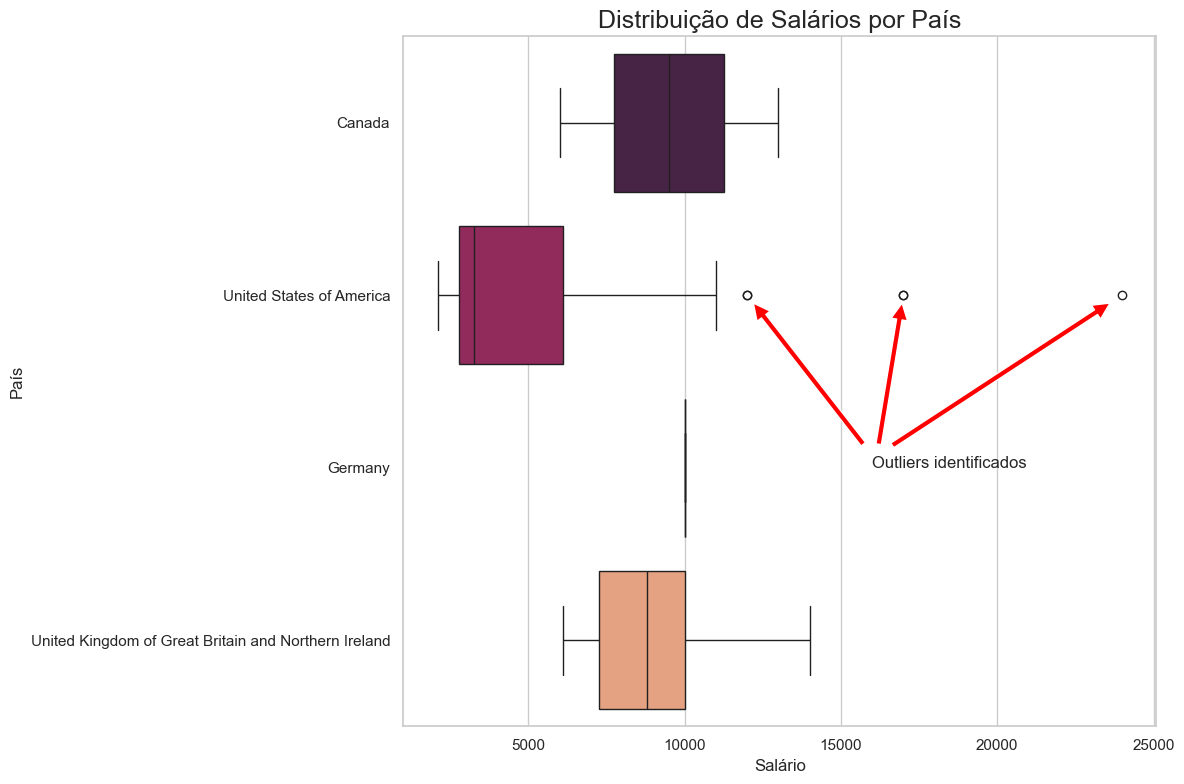

In [64]:
# Configuração de estilo
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Criação do Boxplot
sns.boxplot(
    data=funcionarios,
    x='SALARY',
    y='COUNTRY_NAME',
    hue='COUNTRY_NAME',
    palette='rocket',
    legend=False
)

plt.xlabel('Salário')
plt.ylabel('País')
plt.title('Distribuição de Salários por País', fontsize=18)
plt.tight_layout()
plt.annotate('Outliers identificados', xy=(12000, 1), xytext=(16000, 2),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate(' ', xy=(17000, 1), xytext=(16000, 2),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate(' ', xy=(24000, 1), xytext=(16000, 2),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()

**Análises**

Verifica-se a existência de outliers nos Estados Unidos. Esses outliers correspondem a funcionários dos departamentos Financeiro, Compras, Expedição e TI, com valores de salários significativamente mais altos do que a média dos demais funcionários desses departamentos.